# D1 — Denoising Score Matching & Annealed Langevin Dynamics

**Dataset:** 2D Two Moons  |  **Framework:** PyTorch

**Extension:** Number of noise levels L ∈ {10, 20, 30, 40, 50} — T (Langevin steps) fixed at 100

**Papers:**
- Vincent (2011). *A Connection Between Score Matching and Denoising Autoencoders.*
- Song & Ermon (2019). *Generative Modeling by Estimating Gradients of the Data Distribution.*


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from scipy.stats import wasserstein_distance


In [2]:
torch.manual_seed(42)
np.random.seed(42)


## 1. Dataset — Two Moons


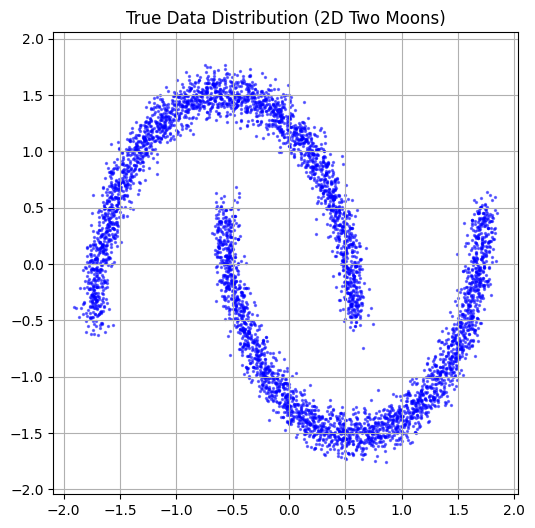

In [3]:
def get_two_moons(n_samples=5000):
    data, _ = make_moons(n_samples=n_samples, noise=0.05)
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
    return torch.tensor(data, dtype=torch.float32)

dataset = get_two_moons(5000)
plt.figure(figsize=(6, 6))
plt.scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color="blue")
plt.title("True Data Distribution (2D Two Moons)")
plt.axis("equal"); plt.grid(True); plt.show()


## 2. Score Network


In [4]:
class ScoreNetwork(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, sigma):
        return self.net(torch.cat([x, sigma], dim=-1))

_m = ScoreNetwork()
assert _m(torch.randn(8, 2), torch.ones(8, 1)).shape == (8, 2)
print(f"Parameters: {sum(p.numel() for p in _m.parameters()):,}")


Parameters: 133,122


## 3. Noise Schedule

Geometric sequence sigma_1 -> sigma_L (Song & Ermon 4.1).
sigma_1 = 1.0 keeps step size alpha_1 = 0.2, preventing chain divergence.


In [5]:
SIGMA_1 = 1.0
SIGMA_L = 0.01
L_TRAIN = 30    # train on 30 levels so network sees full schedule range
EPS     = 2e-5
T_FIXED = 100   # Langevin steps -- FIXED throughout, including extension sweep

def make_schedule(sigma_1, sigma_L, L):
    gamma = (sigma_L / sigma_1) ** (1.0 / (L - 1))
    return torch.tensor([sigma_1 * (gamma ** i) for i in range(L)], dtype=torch.float32)

sigmas_train = make_schedule(SIGMA_1, SIGMA_L, L_TRAIN)

alpha_coarse = EPS * (SIGMA_1**2) / (SIGMA_L**2)
print(f"Training schedule: {L_TRAIN} levels, sigma_1={SIGMA_1}, sigma_L={SIGMA_L}")
print(f"Step size at coarsest level: alpha_1 = {alpha_coarse:.4f}  (safe < 0.5)")


Training schedule: 30 levels, sigma_1=1.0, sigma_L=0.01
Step size at coarsest level: alpha_1 = 0.2000  (safe < 0.5)


## 4. Training

Trained on L_TRAIN=30 levels so the network learns scores across the full schedule range.
Extension varies L only at sampling time using the same trained network.


Epoch [5000/50000] | Loss: 174.1868
Epoch [10000/50000] | Loss: 134.7226
Epoch [15000/50000] | Loss: 127.9071
Epoch [20000/50000] | Loss: 135.4333
Epoch [25000/50000] | Loss: 134.9546
Epoch [30000/50000] | Loss: 199.7982
Epoch [35000/50000] | Loss: 106.7555
Epoch [40000/50000] | Loss: 150.7026
Epoch [45000/50000] | Loss: 149.9884
Epoch [50000/50000] | Loss: 219.7661


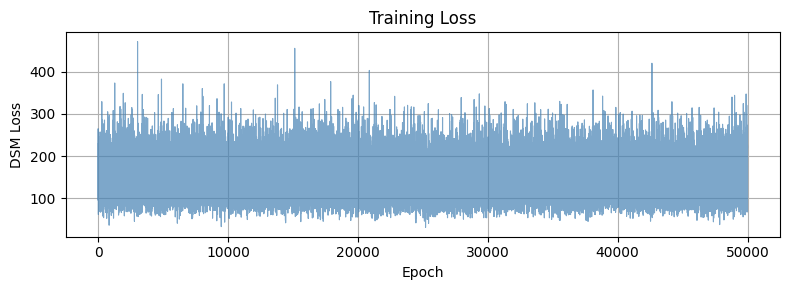

In [6]:
network    = ScoreNetwork(hidden_dim=256)
optimizer  = optim.Adam(network.parameters(), lr=0.001)
epochs     = 50000
batch_size = 128
loss_history = []

for epoch in range(epochs):
    idx       = torch.randint(0, len(dataset), (batch_size,))
    x_clean   = dataset[idx]

    noise_idx = torch.randint(0, L_TRAIN, (batch_size,))
    sigma     = sigmas_train[noise_idx].unsqueeze(-1)

    z         = torch.randn_like(x_clean)
    x_noisy   = x_clean + sigma * z

    # DSM loss: sigma^2 weighted MSE (Song & Ermon eq 5-6; Vincent eq 9)
    # target = -z/sigma = (x - x_noisy)/sigma^2
    target_score    = -z / sigma
    predicted_score = network(x_noisy, sigma)
    loss = 0.5 * torch.mean(
        sigma**2 * torch.sum((predicted_score - target_score)**2, dim=-1)
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 5000 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f}")

plt.figure(figsize=(8, 3))
plt.plot(loss_history, lw=0.8, alpha=0.7, color="steelblue")
plt.xlabel("Epoch"); plt.ylabel("DSM Loss")
plt.title("Training Loss"); plt.grid(True); plt.tight_layout(); plt.show()


## 5. Sampler — Annealed Langevin Dynamics

Algorithm 1 of Song & Ermon (2019). T is fixed throughout.


In [7]:
def sample_annealed_langevin(network, sigmas, n_samples=2000, T=T_FIXED, eps=EPS):
    """
    Song & Ermon (2019) Algorithm 1.
    Update rule (line 6):  x = x + (alpha/2)*score + sqrt(alpha)*z
    Step size  (line 3):   alpha_i = eps * sigma_i^2 / sigma_L^2
    T is passed as a fixed constant -- do not vary it.
    """
    network.eval()
    with torch.no_grad():
        x = torch.randn(n_samples, 2) * sigmas[0]

        for sigma in sigmas:  # coarse -> fine
            alpha        = eps * (sigma**2) / (sigmas[-1]**2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())

            for _ in range(T):  # T fixed
                score = network(x, sigma_tensor)
                z     = torch.randn_like(x)
                x     = x + 0.5 * alpha * score + torch.sqrt(alpha) * z

    return x.numpy()


## 6. Baseline


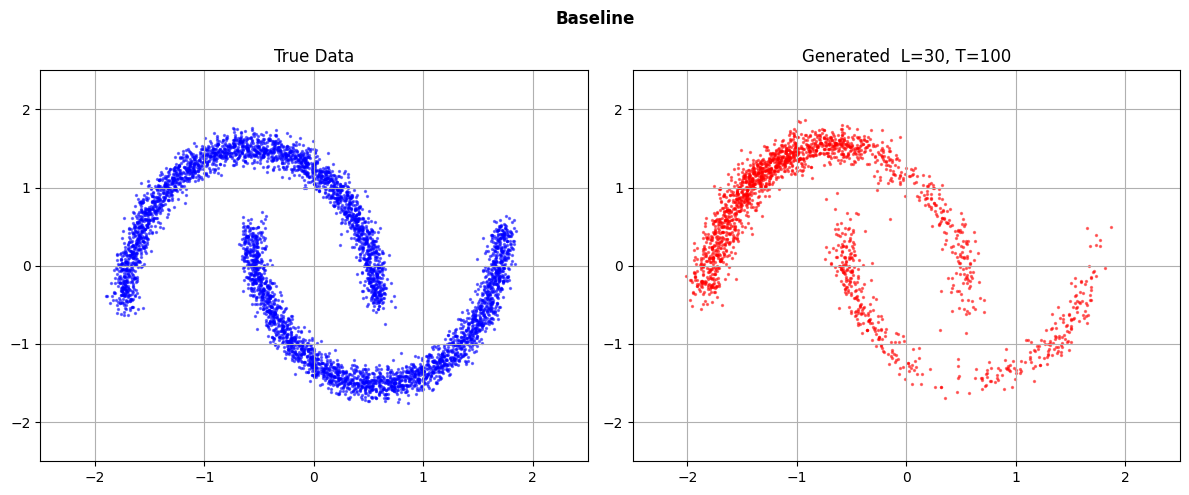

In [8]:
# Always use L_TRAIN so baseline matches training schedule
baseline_sigmas  = make_schedule(SIGMA_1, SIGMA_L, L=L_TRAIN)
baseline_samples = sample_annealed_langevin(network, baseline_sigmas)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color="blue")
axes[0].set_title("True Data"); axes[0].set_xlim(-2.5, 2.5)
axes[0].set_ylim(-2.5, 2.5); axes[0].grid(True)
axes[1].scatter(baseline_samples[:, 0], baseline_samples[:, 1],
                s=2, alpha=0.5, color="red")
axes[1].set_title(f"Generated  L={L_TRAIN}, T={T_FIXED}")
axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)
axes[1].grid(True)
plt.suptitle("Baseline", fontweight="bold")
plt.tight_layout(); plt.show()


## 7. Score Field


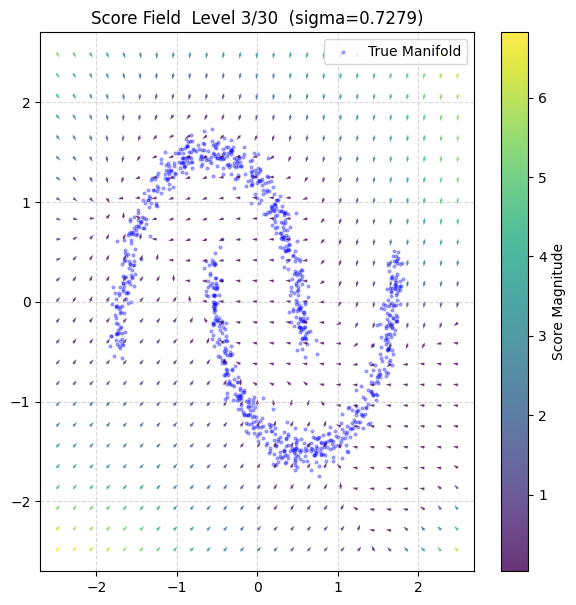

In [9]:
def plot_score_field_grid(network, sigmas, dataset, level_idx=2, grid_res=25):
    network.eval()
    sigma_val = sigmas[level_idx].item()
    lin       = np.linspace(-2.5, 2.5, grid_res)
    X, Y      = np.meshgrid(lin, lin)
    grid_pts  = torch.tensor(
        np.stack([X.flatten(), Y.flatten()], axis=1), dtype=torch.float32
    )
    sig_t = torch.full((grid_pts.shape[0], 1), sigma_val)
    with torch.no_grad():
        scores = network(grid_pts, sig_t).numpy()
    U, V = scores[:, 0].reshape(X.shape), scores[:, 1].reshape(Y.shape)
    mag  = np.sqrt(U**2 + V**2)
    plt.figure(figsize=(7, 7))
    plt.scatter(dataset[:1000, 0], dataset[:1000, 1],
                s=4, color="blue", alpha=0.3, label="True Manifold")
    q = plt.quiver(X, Y, U/mag, V/mag, mag, cmap="viridis",
                   angles="xy", scale_units="xy", scale=15, alpha=0.8)
    plt.colorbar(q, label="Score Magnitude")
    plt.title(f"Score Field  Level {level_idx+1}/{len(sigmas)}  (sigma={sigma_val:.4f})")
    plt.xlim(-2.7, 2.7); plt.ylim(-2.7, 2.7)
    plt.grid(True, linestyle="--", alpha=0.5); plt.legend(); plt.show()

plot_score_field_grid(network, baseline_sigmas, dataset, level_idx=2)


## 8. Extension — Varying L (T fixed at 100)

Single controlled axis: only L changes.
T = 100 is constant across all runs.
all_samples is always reset to {} before the loop to prevent stale cached results.


In [10]:
L_SWEEP    = [10, 20, 30, 40, 50]
all_samples = {}   # ALWAYS reset here -- prevents stale results from previous runs

for L in L_SWEEP:
    sched          = make_schedule(SIGMA_1, SIGMA_L, L)
    samples        = sample_annealed_langevin(network, sched, T=T_FIXED)
    all_samples[L] = samples
    valid = int(np.isfinite(samples).all(axis=1).sum())
    print(f"L={L:<3}  T={T_FIXED}  valid={valid}/2000")


L=10   T=100  valid=2000/2000
L=20   T=100  valid=2000/2000
L=30   T=100  valid=2000/2000
L=40   T=100  valid=2000/2000
L=50   T=100  valid=2000/2000


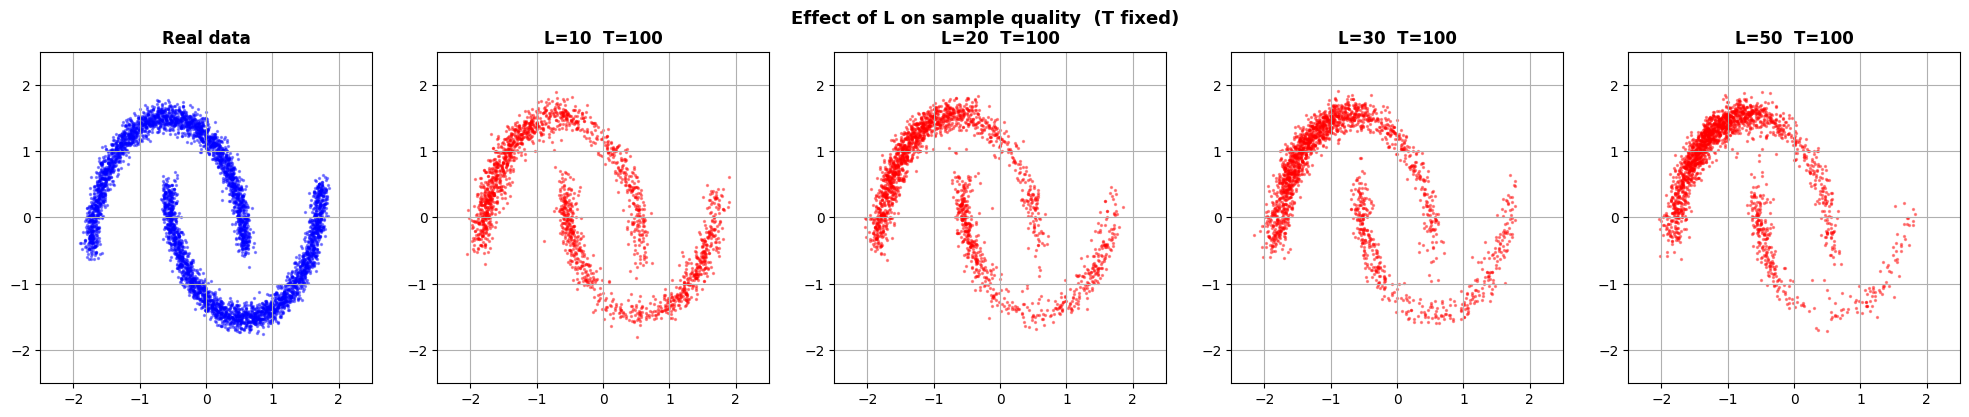

In [11]:
plot_Ls = [10, 20, 30, 50]
fig, axes = plt.subplots(1, len(plot_Ls) + 1,
                          figsize=(4 * (len(plot_Ls) + 1), 4))

axes[0].scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.4, color="blue")
axes[0].set_title("Real data", fontweight="bold")
axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)
axes[0].grid(True); axes[0].set_aspect("equal")

for ax, L in zip(axes[1:], plot_Ls):
    ax.scatter(all_samples[L][:, 0], all_samples[L][:, 1],
               s=2, alpha=0.4, color="red")
    ax.set_title(f"L={L}  T={T_FIXED}", fontweight="bold")
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.grid(True); ax.set_aspect("equal")

plt.suptitle("Effect of L on sample quality  (T fixed)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 9. Evaluation — Sliced Wasserstein Distance

Sliced Wasserstein over 500 random 2D projections.
More reliable than 1D marginal Wasserstein for Two Moons,
which has bimodal structure that marginal metrics cannot capture.


In [12]:
def sliced_wasserstein(p, q, n_proj=500, seed=0):
    """Sliced Wasserstein Distance over random 2D projections.
    More robust than 1D marginal Wasserstein for bimodal distributions.
    """
    rng  = np.random.default_rng(seed)
    dirs = rng.standard_normal((n_proj, p.shape[1]))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    pp   = np.sort(p @ dirs.T, axis=0)
    qp   = np.sort(q @ dirs.T, axis=0)
    n    = min(len(pp), len(qp))
    ip   = np.round(np.linspace(0, len(pp)-1, n)).astype(int)
    iq   = np.round(np.linspace(0, len(qp)-1, n)).astype(int)
    return float(np.mean(np.abs(pp[ip] - qp[iq])))


def wasserstein_score(samples, dataset, n_real=1500):
    """NaN filter then compute Sliced Wasserstein Distance."""
    real = dataset[:n_real].numpy()
    mask = np.isfinite(samples).all(axis=1)
    s    = samples[mask]
    if len(s) == 0:
        return float("inf"), 0
    swd = sliced_wasserstein(real, s)
    return swd, int(mask.sum())


# Theoretical floor: real vs real
tb1   = dataset[torch.randint(0, len(dataset), (1500,))].numpy()
tb2   = dataset[torch.randint(0, len(dataset), (1500,))].numpy()
floor = sliced_wasserstein(tb1, tb2)
print(f"Theoretical floor (real vs real): {floor:.4f}")
print()

results = {}
header  = "  L    T    SWD Score  Valid"
print(header)
print("-" * len(header))
for L in L_SWEEP:
    wd, valid = wasserstein_score(all_samples[L], dataset)
    results[L] = wd
    marker = "  <- baseline" if L == L_TRAIN else ""
    print(f"  {L:<4} {T_FIXED:<4} {wd:<10.4f} {valid}/2000{marker}")


Theoretical floor (real vs real): 0.0315

  L    T    SWD Score  Valid
----------------------------
  10   100  0.2909     2000/2000
  20   100  0.5429     2000/2000
  30   100  0.6318     2000/2000  <- baseline
  40   100  0.7031     2000/2000
  50   100  0.7539     2000/2000


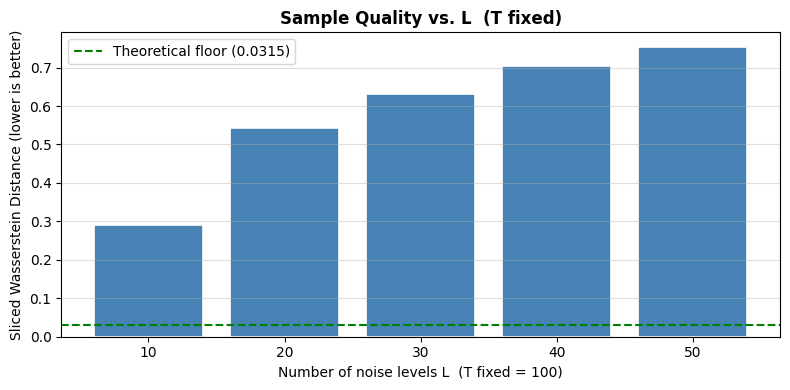

In [13]:
x_pos  = list(range(len(L_SWEEP)))
labels = [str(L) for L in L_SWEEP]
scores = [results[L] for L in L_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos, scores, color="steelblue", edgecolor="white", linewidth=1.2)
ax.axhline(floor, color="green", linestyle="--", lw=1.5,
           label=f"Theoretical floor ({floor:.4f})")
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel(f"Number of noise levels L  (T fixed = {T_FIXED})")
ax.set_ylabel("Sliced Wasserstein Distance (lower is better)")
ax.set_title("Sample Quality vs. L  (T fixed)", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()
